In [1]:
import os

In [ ]:
import paramiko
from scp import SCPClient
import getpass

# This will change after laptop reboot
host = "192.168.100.78"

# This stays constant
user = "ideapad-flex-5\\hugoa"

# TODO: Delete subfolder after done calculating melspecs (or keep a window of 3-5 subfolders or those that cause errors)

# TODO: Songs subfolder '00' is hard-coded
remote_path = 'D:/100-KULIAH/SKRIPSI/mtg-jamendo-dataset-master/rawdata/00/'
local_path = 'E:/SKRIPSI/prep/code/temp/00/'

ssh = paramiko.SSHClient()
is_error = False
while is_error == False:
    try:
        password = getpass.getpass(prompt='Enter laptop password: ') 

        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(host, username=user, password=password)
        is_error = True
    except:
        is_error = False

dir_command = []
song_filenames = []
try:
    _, stdout, _ = ssh.exec_command(command='dir D:\\100-KULIAH\\SKRIPSI\\mtg-jamendo-dataset-master\\rawdata\\00\\')
    dir_command = stdout.readlines()
    
    for item in dir_command:
        j = item.strip()
        if ".mp3" not in j:
            continue
        else:
            tokens = j.split(' ')
            song_filenames.append(tokens[-1])

    print(f'Amount of song files at reomte is: {len(song_filenames)}')

    file_existing = 0
    file_downloaded = 0
    for sf_name in song_filenames:
        if os.path.exists('./temp/00/' + sf_name):
            file_existing += 1
            continue
        else:
            with SCPClient(ssh.get_transport()) as scp:
                scp.get(remote_path + sf_name, local_path, recursive=True)
                file_downloaded += 1

    print(f'{file_existing} song files already exists at ./temp/00; {file_downloaded} new files were downloaded')
except Exception as e:
    print(f"Error: {e}")
finally:
    ssh.close()

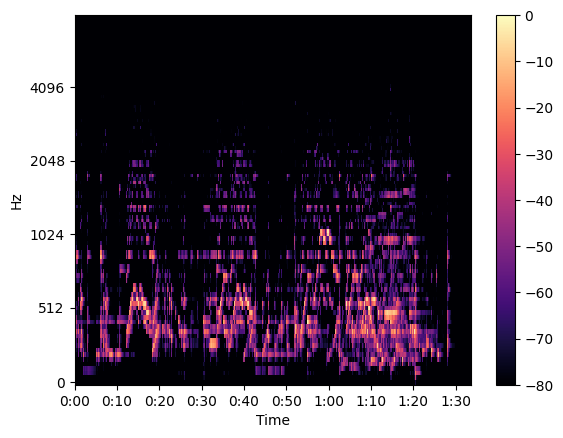

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

INPUT_LEN_SECS = 30
SAMPLE_RATE = 16000
SAMPLES = INPUT_LEN_SECS * SAMPLE_RATE

for song_file in os.scandir('./temp/00'):
    if song_file.is_file():
        y, sr = librosa.load('./temp/00/' + song_file.name, sr=SAMPLE_RATE)
        y_midpoint = len(y) // 2
        before_mid = y_midpoint - (SAMPLES // 2)
        after_mid = y_midpoint + (SAMPLES // 2)

        s = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=96)
        s_db = librosa.amplitude_to_db(np.abs(s), ref=np.max)

        plt.figure()
        librosa.display.specshow(s_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar()
        plt.show()

        break

In [5]:
all_exports = np.empty(shape=(96, 938))
all_exports = []
songfile_order = []

midpoints = []

for song_file in os.scandir('./temp/00'):
    if song_file.is_file():
        y, sr = librosa.load('./temp/00/' + song_file.name, sr=SAMPLE_RATE)
        y_midpoint = len(y) // 2

        before_mid = y_midpoint - (SAMPLES // 2)
        if before_mid < 0:
            before_mid = 0
            after_mid = SAMPLES
        else:
            after_mid = y_midpoint + (SAMPLES // 2)

#         midpoints.append([before_mid, after_mid, after_mid - before_mid])

# from pprint import pprint
# pprint(midpoints)

        s = librosa.feature.melspectrogram(y=y[before_mid:after_mid], sr=sr, n_mels=96)
        s_db = librosa.amplitude_to_db(np.abs(s), ref=np.max)

        songfile_order.append('/00/' + song_file.name)
        all_exports.append(s_db)
        # counter += 1

# print(all_exports)
# print(np.array(all_exports))
all_exports_np = np.array(all_exports)
songfile_order_np = np.array(songfile_order)
print(all_exports_np.shape)
print(songfile_order_np.shape)
np.save('./temp/melspecs/' + '00.npy', all_exports_np)
np.save('./temp/melspecs/' + '00_file_order.npy', songfile_order_np)

(202, 96, 938)
(202,)


/00/1009600.mp3


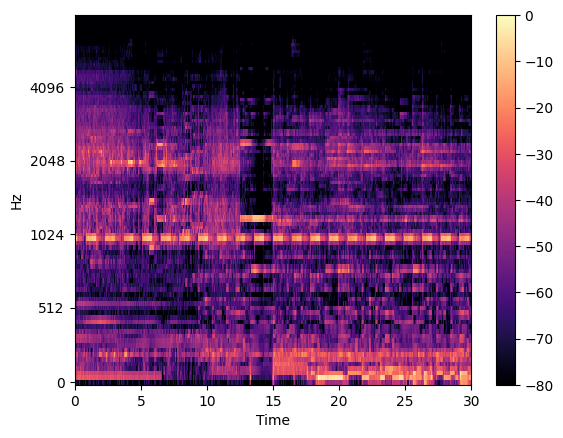

In [6]:
plt.figure()
print(songfile_order[0])
librosa.display.specshow(all_exports[2], sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.show()